In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import torch
import pickle
import os
from tqdm import tqdm

from go_ml.eval_utils import filter_annot_df, gen_annot_mat, gen_seq_len_mask
# from go_ml.model_interp.attention_interp import AttentionExtractor
from go_ml.models.esmc_dropin_attention import AttentionExtractor, find_transformer_blocks

# Load datasets
data_root = '/home/andrew/GO_interp/go_ml/gen_datasets/datasets'
dataset_labels = ['csa', 'llps', 'elms', 'biolip', 
                  'ip_repeat', 'ip_homologous_superfamily', 'ip_domain', 'ip_binding_site', 'ip_active_site']
dataset_dfs = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in dataset_labels]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Load ESMC model
from esm.models.esmc import ESMC

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = ESMC.from_pretrained("esmc_600m").to(device)
model.eval()

# Get number of layers in the model
num_layers = len(model.transformer.blocks) if hasattr(model, 'transformer') else 30
print(f"Model loaded with {num_layers} layers")

Model loaded with 36 layers


In [6]:
from esm.sdk.api import ESMProtein
from esm.utils.constants.esm3 import SEQUENCE_PAD_TOKEN
from transformers import AutoTokenizer
esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D", do_lower_case=False)
selected_layers = [0, num_layers // 4, num_layers // 2, num_layers * 3 // 4, num_layers - 1]  # First, middle, last layers
attn_extractor = AttentionExtractor(model, layer_indices=selected_layers)

In [7]:
# Process each dataset
# Configuration
from go_ml.models.esmc_dropin_attention import extract_attention_for_sequences

output_dir = '/home/andrew/GO_interp/go_ml/dataset_eval/eval_files'
path_label = 'esmc_attention'

for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    save_dir = f'{output_dir}/{ds_label}'
    os.makedirs(save_dir, exist_ok=True)
    save_path = f'{save_dir}/{path_label}.pkl'
    
    if os.path.exists(save_path):
        print(f'Skipping {ds_label}, already done')
        continue
    
    print(f'\n{"="*50}')
    print(f'Processing {ds_label} ({len(annot_df)} sequences)')
    print(f'{"="*50}')
    
    sequences = annot_df['Sequence'].tolist()
    uniprot_ids = annot_df['UniprotID'].tolist()
    
    # Extract attention maps
    attn_data = extract_attention_for_sequences(
        sequences, model, attn_extractor, esm_tokenizer,
        layer_indices=selected_layers, batch_size=4, aggregate_heads='mean'
    )
    for layer_idx in attn_data:
        print(f"Layer {layer_idx}: {len(attn_data[layer_idx])} sequences' attention extracted")
        attn_imp = torch.zeros((len(sequences), 852))
        for i in range(len(sequences)):
            attn_imp[i, :attn_data[layer_idx][i].shape[0]] = attn_data[layer_idx][i]
        attn_data[layer_idx] = attn_imp
    
    save_dict = {
        'UniprotID': uniprot_ids,
        'selected_layers': selected_layers,
        'attn_data': attn_data #Attn importance scores from each layer
    }
    
    with open(save_path, 'wb') as f:
        pickle.dump(save_dict, f)

    print(f'Saved {ds_label} attention scores to {save_path}')

print('\nDone processing all datasets!')


Processing csa (784 sequences)


Extracting attention:   0%|          | 0/196 [00:00<?, ?it/s]

Extracting attention: 100%|██████████| 196/196 [03:47<00:00,  1.16s/it]


Layer 0: 784 sequences' attention extracted
Layer 9: 784 sequences' attention extracted
Layer 18: 784 sequences' attention extracted
Layer 27: 784 sequences' attention extracted
Layer 35: 784 sequences' attention extracted
Saved csa attention scores to /home/andrew/GO_interp/go_ml/dataset_eval/eval_files/csa/esmc_attention.pkl

Processing llps (53 sequences)


Extracting attention: 100%|██████████| 14/14 [00:19<00:00,  1.38s/it]


...

Layer 0: 179 sequences' attention extracted
Layer 9: 179 sequences' attention extracted
Layer 18: 179 sequences' attention extracted
Layer 27: 179 sequences' attention extracted
Layer 35: 179 sequences' attention extracted
Saved ip_domain attention scores to /home/andrew/GO_interp/go_ml/dataset_eval/eval_files/ip_domain/esmc_attention.pkl

Processing ip_binding_site (462 sequences)


Extracting attention: 100%|██████████| 116/116 [02:10<00:00,  1.13s/it]


Layer 0: 462 sequences' attention extracted
Layer 9: 462 sequences' attention extracted
Layer 18: 462 sequences' attention extracted
Layer 27: 462 sequences' attention extracted
Layer 35: 462 sequences' attention extracted
Saved ip_binding_site attention scores to /home/andrew/GO_interp/go_ml/dataset_eval/eval_files/ip_binding_site/esmc_attention.pkl

Processing ip_active_site (465 sequences)


Extracting attention: 100%|██████████| 117/117 [02:00<00:00,  1.03s/it]

Layer 0: 465 sequences' attention extracted
Layer 9: 465 sequences' attention extracted
Layer 18: 465 sequences' attention extracted
Layer 27: 465 sequences' attention extracted
Layer 35: 465 sequences' attention extracted
Saved ip_active_site attention scores to /home/andrew/GO_interp/go_ml/dataset_eval/eval_files/ip_active_site/esmc_attention.pkl

Done processing all datasets!


In [ ]:

sequences = dataset_dfs[0]['Sequence'].tolist()[:25]
attn_data = extract_attention_for_sequences(
    sequences, model, attn_extractor, esm_tokenizer,
    layer_indices=selected_layers, batch_size=4, aggregate_heads='mean'
)
for layer_idx in attn_data:
    print(f"Layer {layer_idx}: {len(attn_data[layer_idx])} sequences' attention extracted")
    attn_imp = torch.zeros((len(sequences), 852))
    for i in range(len(sequences)):
        attn_imp[i, :attn_data[layer_idx][i].shape[0]] = attn_data[layer_idx][i]
    attn_data[layer_idx] = attn_imp

Extracting attention:   0%|          | 0/7 [00:00<?, ?it/s]

Extracting attention: 100%|██████████| 7/7 [00:08<00:00,  1.28s/it]


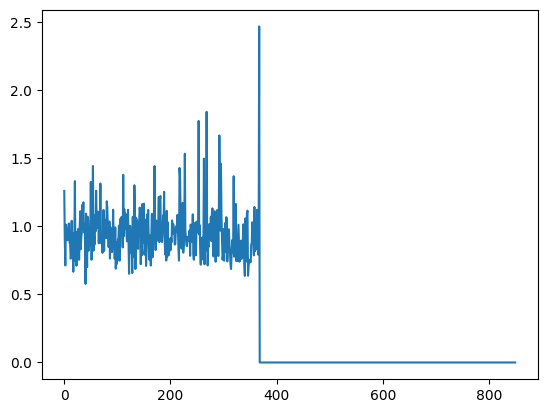

In [14]:
import matplotlib.pyplot as plt
plt.plot(attn_imp[0][1:-1])


In [27]:
attn_data.keys()

dict_keys([0, 18, 35])

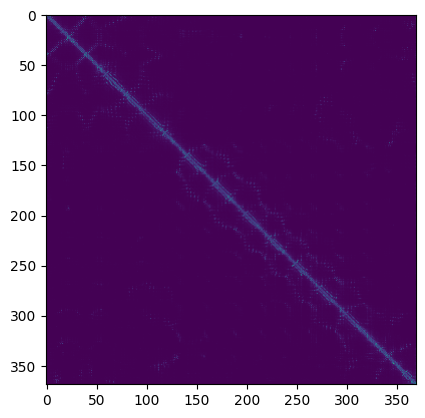

In [24]:
import matplotlib.pyplot as plt
plt.imshow(attn_data[35][0])

In [3]:
# model._use_flash_attn = False  # Disable flash attention for interpretability

In [ ]:

for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    print(f'\n{"="*50}')
    print(f'Processing {ds_label} ({len(annot_df)} sequences)')
    print(f'{"="*50}')
    
    sequences = annot_df['Sequence'].tolist()[:25]
    uniprot_ids = annot_df['UniprotID'].tolist()[:25]

    


Processing csa (784 sequences)


In [ ]:


# Select which layers to extract (e.g., first, middle, last)
# For full model, this might be layers [0, 14, 29] for a 30-layer model
selected_layers = [0, num_layers // 2, num_layers - 1]  # First, middle, last layers
print(f"Will extract attention from layers: {selected_layers}")

Will extract attention from layers: [0, 18, 35]



Processing csa (784 sequences)
torch.Size([10, 714])
attn
attn
attn


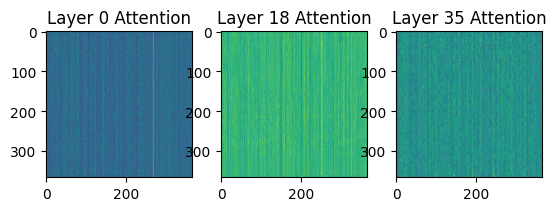

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3)
for i, layer_idx in enumerate(selected_layers):
    attn_map = attn_weights[layer_idx][0].cpu().numpy()[:367, :367]  # Average over heads for first sequence
    ax[i].imshow(attn_map, cmap='viridis')
    ax[i].set_title(f'Layer {layer_idx} Attention')

In [ ]:
# Optional: Load and inspect saved attention maps
import matplotlib.pyplot as plt

def visualize_attention(ds_label, seq_idx=0):
    """Visualize attention maps for a specific sequence."""
    save_path = f'{output_dir}/{ds_label}/{path_label}.pkl'
    
    if not os.path.exists(save_path):
        print(f"No attention data found for {ds_label}")
        return
    
    with open(save_path, 'rb') as f:
        data = pickle.load(f)
    
    uniprot_id = data['UniprotID'][seq_idx]
    seq_len = int(data['seq_len_mask'][seq_idx].sum())
    
    # Get annotation mask for this sequence
    annot_mask = data['annot_mat'][seq_idx][:seq_len]
    
    # Plot attention maps for each layer
    n_layers = len(data['selected_layers'])
    fig, axes = plt.subplots(1, n_layers + 1, figsize=(5 * (n_layers + 1), 4))
    
    for i, layer_idx in enumerate(data['selected_layers']):
        attn = data[f'layer_{layer_idx}'][seq_idx, :seq_len, :seq_len]
        
        ax = axes[i]
        im = ax.imshow(attn, cmap='viridis', aspect='auto')
        ax.set_title(f'Layer {layer_idx}')
        ax.set_xlabel('Key Position')
        ax.set_ylabel('Query Position')
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Plot column-wise attention sum
    ax = axes[-1]
    for layer_idx in data['selected_layers']:
        col_attn = data[f'layer_{layer_idx}_col_sum'][seq_idx, :seq_len]
        ax.plot(col_attn, label=f'Layer {layer_idx}', alpha=0.7)
    
    # Highlight annotated regions
    annot_regions = np.where(annot_mask > 0)[0]
    if len(annot_regions) > 0:
        ax.axvspan(annot_regions[0], annot_regions[-1], alpha=0.2, color='red', label='Annotated Region')
    
    ax.set_title(f'Column-wise Attention Sum\n{uniprot_id}')
    ax.set_xlabel('Position')
    ax.set_ylabel('Attention Sum')
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return data

# Example usage (uncomment after running extraction):
# visualize_attention('csa', seq_idx=0)